# Классификация текстов с использованием Наивного Байесовского Классификатора

## Задание 1 (1 балл)

Откройте данные. Узнайте, сколько в них спам- и не спам-писем. Визуализируйте полученные соотношение подходящим образом.

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import model_selection
import warnings
warnings.filterwarnings('ignore')

# Прочитаем файл с исходными данными:
data = pd.read_csv('spam_or_not_spam.csv')

# Выведем результат на экран:
data.head()

,email,label
0,date wed NUMBER aug NUMBER NUMBER NUMBER NUMB...,0
1,martin a posted tassos papadopoulos the greek ...,0
2,man threatens explosion in moscow thursday aug...,0
3,klez the virus that won t die already the most...,0
4,in adding cream to spaghetti carbonara which ...,0


In [50]:
# Рассчитаем частоты для классов:
data.groupby('label').count()

,email
label,
0,2500
1,499


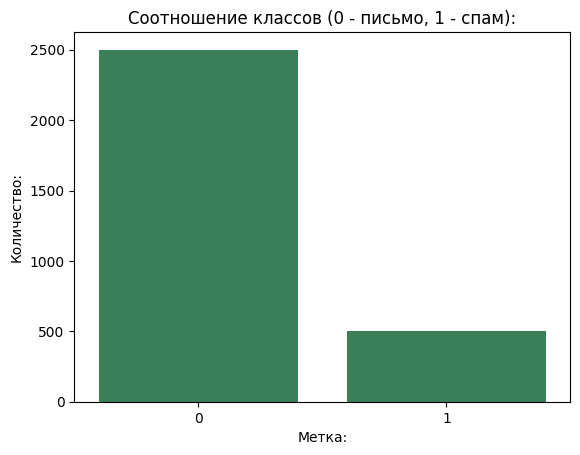

In [51]:
# Визуализируем результат:

sns.countplot(data = data,
              x =  'label',
              orient = 'h',
              color = 'seagreen',
              stat = 'count',
              legend = 'auto')

# Настройка заголовков осей координат:
plt.xlabel('Метка:')
plt.ylabel('Количество:')
# Настройка заголовка и отображение графика:
plt.title('Соотношение классов (0 - письмо, 1 - спам):')
plt.show()

## Задание 2 (2 балла)

Вам необходимо предобработать ваши данные и перевести их в векторный вид. Подгрузим необходимый модуль:

In [52]:
from sklearn.feature_extraction.text import CountVectorizer

Замените в данных все пустые строки и строки, состоящие из пробелов, на пропуски (NaN). После этого удалите из данных все строки, в которых наблюдаются пропущенные значения.

In [53]:
data = data.dropna(axis=0)

Переводим данные в векторный вид:

In [54]:
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(data["email"])

Определите, сколько теперь признаков в нашем наборе данных:

In [55]:
X.shape

(2999, 34116)

## Задание 3 (2 балла)

Определите целевую переменную и признаки:

In [56]:
X = X
y = data['label']

Разделите выборку на обучающую и тестовую, используя стратифицированное разбиение (параметр `stratify` установите в значение вектора ответов y) размер тестовой выборки (`test_size`) возьмите как 0.25, параметр `random_state` определите со значением 42:

In [57]:
X_train, X_test, y_train, y_test = model_selection.train_test_split(
    X, y, 
    stratify = y, 
    random_state =  42,
    test_size = 0.25
)
print('Train shape: {}'.format(X_train.shape))
print('Test shape: {}'.format(X_test.shape))

Train shape: (2249, 34116)
Test shape: (750, 34116)


Рассчитайте среднее значение целевой переменной по тестовой выборке:

In [63]:
y_test.mean()

0.16666666666666666

## Задание 4 (3 балла)

Определите и обучите подходящий алгоритм с параметром alpha = 0.01

In [59]:
#ваш код здесь

Оцените результат с точки зрения всех известных вам метрик (не менее трёх):

In [60]:
#ваш код здесь

Нарисуйте ROC-кривую:

In [61]:
#ваш код здесь

## Задание 5 (3 балла)

Переберите несколько значений alpha с помощью кросс-валидации. Оцените, зависит ли от этого параметра качество классификации.

In [62]:
#ваш код здесь